In [45]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vaclavpechtor/rvl-cdip-small-200/rvl-cdip-small-200/val/scientific_report/2501747592_7593.tif
/kaggle/input/datasets/vaclavpechtor/rvl-cdip-small-200/rvl-cdip-small-200/val/scientific_report/1000827867_1000827869.tif
/kaggle/input/datasets/vaclavpechtor/rvl-cdip-small-200/rvl-cdip-small-200/val/scientific_report/2505116322.tif
/kaggle/input/datasets/vaclavpechtor/rvl-cdip-small-200/rvl-cdip-small-200/val/scientific_report/2504046077.tif
/kaggle/input/datasets/vaclavpechtor/rvl-cdip-small-200/rvl-cdip-small-200/val/scientific_report/2024493246-a.tif
/kaggle/input/datasets/vaclavpechtor/rvl-cdip-small-200/rvl-cdip-small-200/val/scientific_report/2055626759.tif
/kaggle/input/datasets/vaclavpechtor/rvl-cdip-small-200/rvl-cdip-small-200/val/scientific_report/2082740426.tif
/kaggle/input/datasets/vaclavpechtor/rvl-cdip-small-200/rvl-cdip-small-200/val/scientific_report/2505473647_3650.tif
/kaggle/input/datasets/vaclavpechtor/rvl-cdip-small-200/rvl-cdip-small-200/val/sc

In [46]:
# =========================
# 1. Import Libraries
# =========================

import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

In [47]:
# =========================
# 2. Device Setup
# =========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [48]:
# =========================
# 3. Dataset Paths
# =========================

BASE_DIR = "/kaggle/input/datasets/vaclavpechtor/rvl-cdip-small-200/rvl-cdip-small-200"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")

print("Train folder exists:", os.path.exists(TRAIN_DIR))
print("Val folder exists:", os.path.exists(VAL_DIR))

print("Train folders:", os.listdir(TRAIN_DIR)[:10])
print("Val folders:", os.listdir(VAL_DIR)[:10])

Train folder exists: True
Val folder exists: True
Train folders: ['scientific_report', 'resume', 'memo', 'file_folder', 'specification', 'news_article', 'letter', 'form', 'budget', 'handwritten']
Val folders: ['scientific_report', 'resume', 'memo', 'file_folder', 'specification', 'news_article', 'letter', 'form', 'budget', 'handwritten']


In [49]:
# =========================
# 4. Improved Image Transformations
# =========================

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [50]:
# =========================
# 5. Load Dataset Correctly
# =========================

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transform)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Classes:", train_dataset.classes)
print("Number of classes:", len(train_dataset.classes))

Training images: 2560
Validation images: 640
Classes: ['advertisement', 'budget', 'email', 'file_folder', 'form', 'handwritten', 'invoice', 'letter', 'memo', 'news_article', 'presentation', 'questionnaire', 'resume', 'scientific_publication', 'scientific_report', 'specification']
Number of classes: 16


In [51]:
# =========================
# 6. Create Data Loaders
# =========================

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

test_loader = val_loader

In [52]:
# =========================
# 7. Build Improved ResNet50 Model
# =========================

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

num_features = model.fc.in_features
num_classes = len(train_dataset.classes)

model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features, num_classes)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

print("Model: ResNet50")
print("Number of output classes:", num_classes)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 218MB/s]


Model: ResNet50
Number of output classes: 16


In [53]:
# =========================
# 8. Train the Model
# =========================

epochs = 15

train_losses = []
val_accuracies = []

best_val_acc = 0.0
best_model_path = "best_resnet50_document_model.pth"

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total
    val_accuracies.append(val_accuracy)

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), best_model_path)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Validation Accuracy: {val_accuracy:.2f}% | Best: {best_val_acc:.2f}%")

Epoch [1/15] | Loss: 2.4791 | Validation Accuracy: 43.44% | Best: 43.44%
Epoch [2/15] | Loss: 1.6514 | Validation Accuracy: 57.03% | Best: 57.03%
Epoch [3/15] | Loss: 1.3049 | Validation Accuracy: 59.22% | Best: 59.22%
Epoch [4/15] | Loss: 1.0564 | Validation Accuracy: 62.66% | Best: 62.66%
Epoch [5/15] | Loss: 0.8447 | Validation Accuracy: 64.22% | Best: 64.22%
Epoch [6/15] | Loss: 0.6446 | Validation Accuracy: 67.81% | Best: 67.81%
Epoch [7/15] | Loss: 0.5377 | Validation Accuracy: 66.41% | Best: 67.81%
Epoch [8/15] | Loss: 0.4353 | Validation Accuracy: 66.72% | Best: 67.81%
Epoch [9/15] | Loss: 0.4020 | Validation Accuracy: 68.75% | Best: 68.75%
Epoch [10/15] | Loss: 0.3300 | Validation Accuracy: 69.22% | Best: 69.22%
Epoch [11/15] | Loss: 0.2495 | Validation Accuracy: 70.16% | Best: 70.16%
Epoch [12/15] | Loss: 0.2130 | Validation Accuracy: 70.31% | Best: 70.31%
Epoch [13/15] | Loss: 0.1995 | Validation Accuracy: 69.69% | Best: 70.31%
Epoch [14/15] | Loss: 0.1698 | Validation Accur

In [54]:
# =========================
# 9. Load Best Model
# =========================

model.load_state_dict(torch.load(best_model_path))
model.eval()

print("Best model loaded.")
print("Best validation accuracy:", round(best_val_acc, 2), "%")

Best model loaded.
Best validation accuracy: 70.31 %


In [55]:
# =========================
# 10. Final Evaluation
# =========================

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

test_accuracy = accuracy_score(all_labels, all_preds)

print("Test Accuracy:", round(test_accuracy * 100, 2), "%")
print("\nClassification Report:\n")
print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
))

Test Accuracy: 70.31 %

Classification Report:

                        precision    recall  f1-score   support

         advertisement       0.74      0.78      0.76        40
                budget       0.51      0.62      0.56        40
                 email       0.92      0.82      0.87        40
           file_folder       0.92      0.88      0.90        40
                  form       0.53      0.68      0.59        40
           handwritten       0.85      0.82      0.84        40
               invoice       0.77      0.50      0.61        40
                letter       0.71      0.62      0.67        40
                  memo       0.73      0.75      0.74        40
          news_article       0.94      0.72      0.82        40
          presentation       0.47      0.68      0.56        40
         questionnaire       0.74      0.65      0.69        40
                resume       0.84      0.90      0.87        40
scientific_publication       0.84      0.78      0.81  

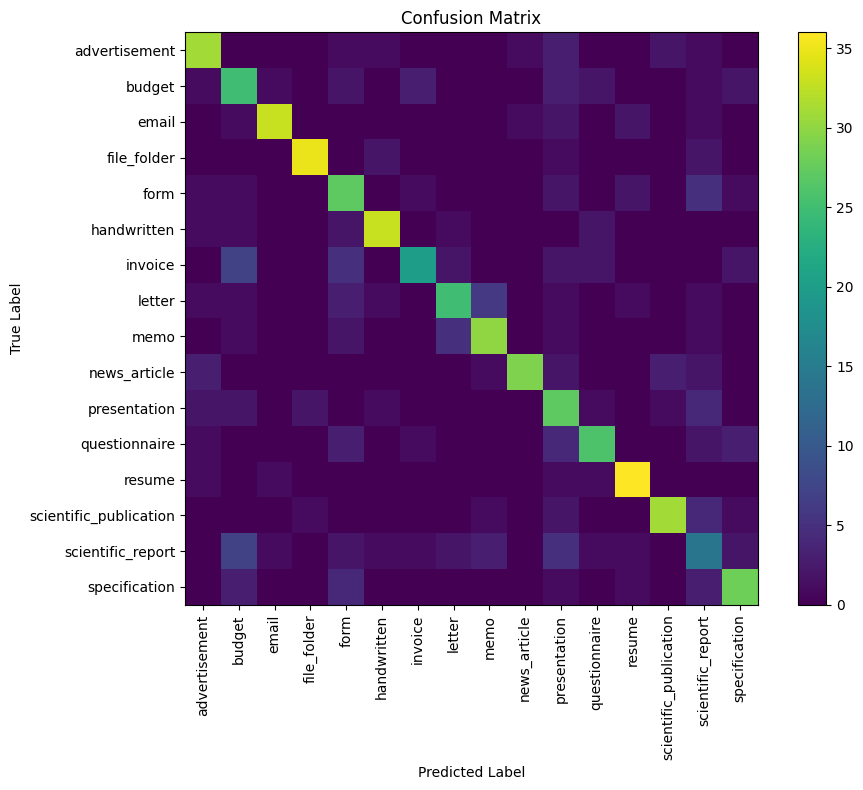

In [56]:
# =========================
# 11. Confusion Matrix
# =========================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(
    ticks=np.arange(len(train_dataset.classes)),
    labels=train_dataset.classes,
    rotation=90
)

plt.yticks(
    ticks=np.arange(len(train_dataset.classes)),
    labels=train_dataset.classes
)

plt.tight_layout()
plt.show()

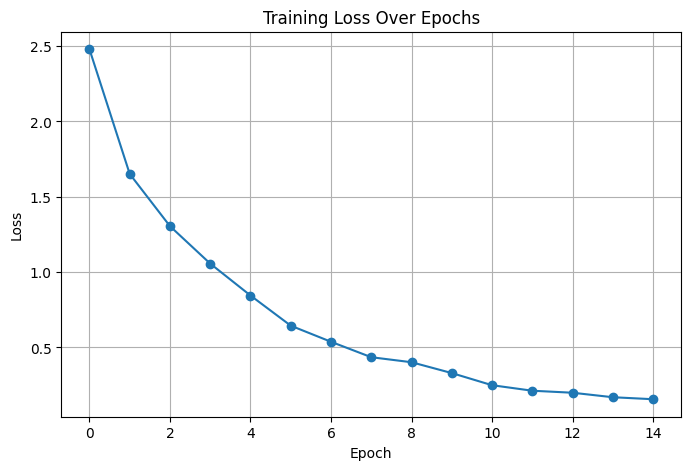

In [57]:
# =========================
# 12. Training Loss Graph
# =========================

plt.figure(figsize=(8, 5))
plt.plot(train_losses, marker='o')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

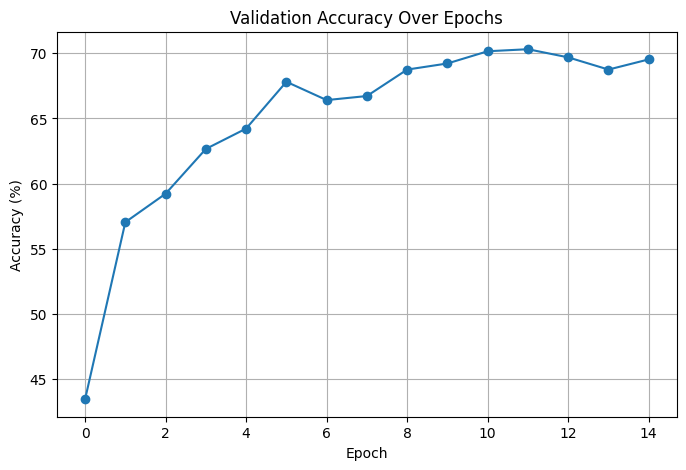

In [58]:
# =========================
# 13. Validation Accuracy Graph
# =========================

plt.figure(figsize=(8, 5))
plt.plot(val_accuracies, marker='o')
plt.title("Validation Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

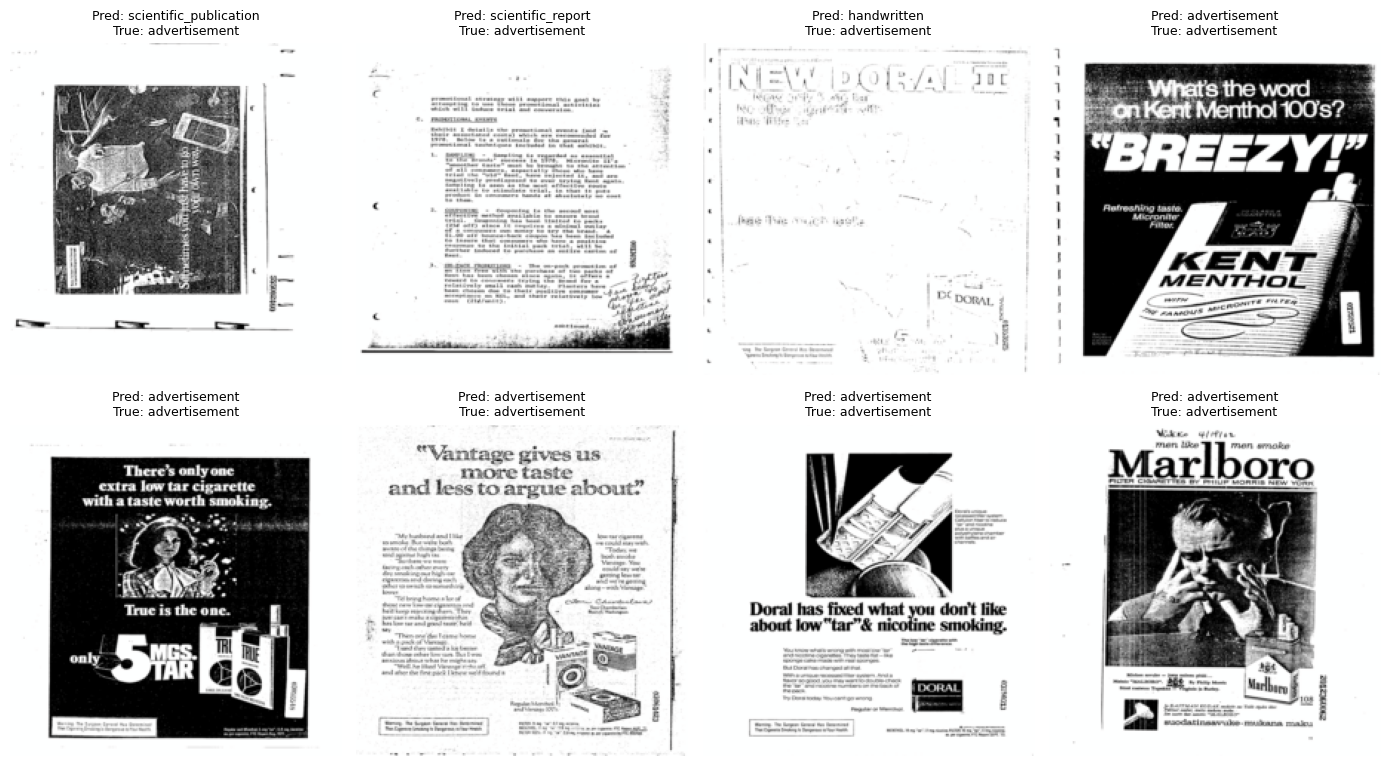

In [59]:
# =========================
# 14. Sample Predictions
# =========================

images, labels = next(iter(test_loader))

images_gpu = images.to(device)
outputs = model(images_gpu)
_, preds = torch.max(outputs, 1)

plt.figure(figsize=(14, 8))

for i in range(min(8, len(images))):
    img = images[i].permute(1, 2, 0).numpy()

    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    pred_label = train_dataset.classes[preds[i].item()]
    true_label = train_dataset.classes[labels[i].item()]

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()